# Wikipedia Text Games Exercise
In this exercise, we'll analyze the text from a Wikipedia page. We will get experience working with Python lists, dictionaries and sets and review the materials we learned in Lesson 1.

In [104]:
# First let's get the contents of the webpage, as raw html
# i downloaded the site because i didnt want to setup the agent - user stuff wikipedia requires now
with open('Data science - Wikipedia.htm', 'r', encoding='utf-8') as f:
    html = f.read()
html

'<!DOCTYPE html>\n<html class="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 skin-theme-clientpref-day vector-toc-available skin-thumbsize-clientpref-standard vector-animations-ready ve-available vector-feature-toc-pinned-clientpref-1 vector-feature-appearance-pinned-clientpref-1" lang="en" dir="ltr"><head>\n<meta http-equiv="content-type" content="text/html; charset=UTF-8">\n<meta charset="UTF-8">\n<title>Data science - Wikipedia</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-f

In [105]:
# Now let's strip the html tags, and keep the page text
from bs4 import BeautifulSoup

def html2text(html):
    # Pass the file content directly to BeautifulSoup
    soup = BeautifulSoup(html, "html.parser")

    # kill all script and style elements
    for script in soup(["script", "style"]):
        script.extract()    # rip it out

    # get text
    text = soup.get_text()
    # break into lines and remove leading and trailing space on each
    lines = [line.strip() for line in text.splitlines()]
    # drop blank lines
    text = [line for line in lines if line]

    return text

In [106]:
text = html2text(html)
text

['Data science - Wikipedia',
 'Jump to content',
 'Main menu',
 'Main menu',
 'move to sidebar',
 'hide',
 'Navigation',
 'Main pageContentsCurrent eventsRandom articleAbout WikipediaContact us',
 'Contribute',
 'HelpLearn to editCommunity portalRecent changesUpload fileSpecial pages',
 'Search',
 'Search',
 'Appearance',
 'Donate',
 'Create account',
 'Log in',
 'Personal tools',
 'Donate',
 'Create account',
 'Log in',
 'Contents',
 'move to sidebar',
 'hide',
 '(Top)',
 '1',
 'Foundations',
 '2',
 'Etymology',
 'Toggle Etymology subsection',
 '2.1',
 'Early usage',
 '2.2',
 'Modern usage',
 '3',
 'Data science and data analysis',
 '4',
 'Cloud computing for data science',
 '5',
 'Ethical consideration in data science',
 '6',
 'See also',
 '7',
 'References',
 'Toggle the table of contents',
 'Data science',
 '54 languages',
 'العربيةAzərbaycancaБългарскиবাংলাCatalàکوردیČeštinaDeutschΕλληνικάEsperantoEspañolEestiEuskaraفارسیSuomiFrançaisGalegoעבריתहिन्दीMagyarՀայերենBahasa IndonesiaI

In [107]:
import re

def tokenize_sentences(sentences):
    tokenized_sentences = []
    for sentence in sentences:
        # Convert sentence to lowercase
        sentence = sentence.lower()
        
        # Tokenize sentence into words and remove non-alphanumeric characters
        words = re.findall(r'\w+', sentence)
        
        # Append tokenized sentence to list
        tokenized_sentences.append(words)
    
    return tokenized_sentences

In [108]:
import re

def tokenize_sentences(sentences):
    tokenized_sentences = []
    
    for sentence in sentences:
        sentence = sentence.lower()
        words = re.findall(r'\w+', sentence)
        tokenized_sentences.extend(words)
    
    return tokenized_sentences


tokenized_text = tokenize_sentences(text)


In [109]:
tokenized_text

['data',
 'science',
 'wikipedia',
 'jump',
 'to',
 'content',
 'main',
 'menu',
 'main',
 'menu',
 'move',
 'to',
 'sidebar',
 'hide',
 'navigation',
 'main',
 'pagecontentscurrent',
 'eventsrandom',
 'articleabout',
 'wikipediacontact',
 'us',
 'contribute',
 'helplearn',
 'to',
 'editcommunity',
 'portalrecent',
 'changesupload',
 'filespecial',
 'pages',
 'search',
 'search',
 'appearance',
 'donate',
 'create',
 'account',
 'log',
 'in',
 'personal',
 'tools',
 'donate',
 'create',
 'account',
 'log',
 'in',
 'contents',
 'move',
 'to',
 'sidebar',
 'hide',
 'top',
 '1',
 'foundations',
 '2',
 'etymology',
 'toggle',
 'etymology',
 'subsection',
 '2',
 '1',
 'early',
 'usage',
 '2',
 '2',
 'modern',
 'usage',
 '3',
 'data',
 'science',
 'and',
 'data',
 'analysis',
 '4',
 'cloud',
 'computing',
 'for',
 'data',
 'science',
 '5',
 'ethical',
 'consideration',
 'in',
 'data',
 'science',
 '6',
 'see',
 'also',
 '7',
 'references',
 'toggle',
 'the',
 'table',
 'of',
 'contents',
 'd

1. Create a histogram for the words in the text. What is the most common word?

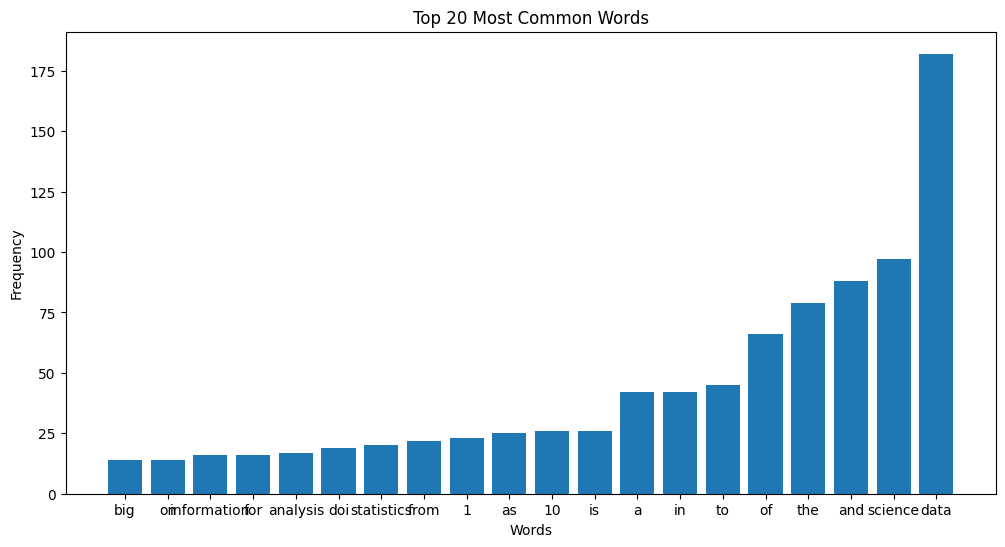

The most common word is 'data' with 182 occurrences.


In [110]:
from collections import Counter
import matplotlib.pyplot as plt

# Count word frequencies
word_counts = Counter(tokenized_text)

# Create histogram
top_words = word_counts.most_common(20)[::-1]
words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(12, 6))
plt.bar(words, counts)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Common Words')
plt.show()

# Find most common word
most_common_word = word_counts.most_common(1)[0]
print(f"The most common word is '{most_common_word[0]}' with {most_common_word[1]} occurrences.")

Display the words sorted in descending order by number of occurrences.

In [111]:
# Display words sorted in descending order by number of occurrences
sorted_words = word_counts.most_common()
print("Words sorted by occurrences (descending):")
for word, count in sorted_words[:50]:  # Show first 50
    print(f"{word}: {count}")

Words sorted by occurrences (descending):
data: 182
science: 97
and: 88
the: 79
of: 66
to: 45
in: 42
a: 42
is: 26
10: 26
as: 25
1: 23
from: 22
statistics: 20
doi: 19
analysis: 17
for: 16
information: 16
on: 14
big: 14
retrieved: 14
2: 13
with: 13
edit: 12
that: 12
statistical: 12
computing: 11
field: 10
an: 10
issn: 10
4: 9
knowledge: 9
computer: 9
processing: 9
business: 9
learning: 9
april: 9
or: 8
by: 8
research: 8
it: 8
such: 8
21st: 8
century: 8
2013: 8
october: 8
2016: 8
3: 7
what: 7
methods: 7


How many words appear only once in the text? These are called `hapax legomenon`.

In [112]:
# Count hapax legomenon (words that appear only once)
hapax_legomenon = [word for word, count in word_counts.items() if count == 1]
print(f"Number of hapax legomenon (words appearing only once): {len(hapax_legomenon)}")

Number of hapax legomenon (words appearing only once): 863


What's the longest sentence?

In [113]:
# Find the longest sentence
longest_sentence = max(text, key=len)
print(f"The longest sentence is:\n{longest_sentence}\n")
print(f"Length: {len(longest_sentence)} characters")

The longest sentence is:
Data science is "a concept to unify statistics, data analysis, informatics, and their related methods" to "understand and analyze actual phenomena" with data.[6] It uses techniques and theories drawn from many fields within the context of mathematics, statistics, computer science, information science, and domain knowledge.[7] However, data science is distinct from computer science and information science. Turing Award winner Jim Gray imagined data science as a "fourth paradigm" of science (empirical, theoretical, computational, and now data-driven) and asserted that "everything about science is changing because of the impact of information technology" and the data deluge.[8][9]

Length: 686 characters


How many unique words are in the document?

In [114]:
# Count unique words in the document
unique_words = len(set(tokenized_text))
print(f"Number of unique words in the document: {unique_words}")

Number of unique words in the document: 1278


What's the average number of times each word appears?

In [115]:
# Calculate average number of times each word appears
total_words = len(tokenized_text)
unique_words_count = len(set(tokenized_text))
avg_occurrences = total_words / unique_words_count
print(f"Average number of times each word appears: {avg_occurrences:.2f}")

Average number of times each word appears: 2.41


What's the most common letter? What's the least common?

In [116]:
# Find most and least common letters
all_text = ' '.join(tokenized_text)
letter_counts = Counter(all_text)
# Filter only letters (a-z)
letter_counts = {k: v for k, v in letter_counts.items() if k.isalpha()}
most_common_letter = max(letter_counts.items(), key=lambda x: x[1])
least_common_letter = min(letter_counts.items(), key=lambda x: x[1])
print(f"Most common letter: '{most_common_letter[0]}' with {most_common_letter[1]} occurrences")
print(f"Least common letter: '{least_common_letter[0]}' with {least_common_letter[1]} occurrences")

Most common letter: 'e' with 1679 occurrences
Least common letter: 'ل' with 1 occurrences


Which words appear in both the first half of the document and the second half?

In [117]:
# Find words that appear in both the first half and second half of the document
mid_point = len(text) // 2
first_half = text[:mid_point]
second_half = text[mid_point:]

# Tokenize each half
first_half_words = set()
for sentence in first_half:
    words = re.findall(r'\w+', sentence.lower())
    first_half_words.update(words)

second_half_words = set()
for sentence in second_half:
    words = re.findall(r'\w+', sentence.lower())
    second_half_words.update(words)

# Find intersection
common_words = first_half_words.intersection(second_half_words)
print(f"Number of words appearing in both halves: {len(common_words)}")
print(f"Sample of common words: {list(common_words)[:20]}")

Number of words appearing in both halves: 206
Sample of common words: ['times', 'long', 'reilly', 'an', 'analysis', 'description', 'about', 'topological', 'languages', 'its', 'toggle', 'storage', 'provost', 'research', 'review', 'code', 'from', 'what', 'september', '50']


Are there any palindromes in the text?

In [118]:
# Find palindromes in the text
def is_palindrome(word):
    return word == word[::-1] and len(word) > 1

palindromes = set()
for word in tokenized_text:
    if is_palindrome(word):
        palindromes.add(word)

print(f"Palindromes found in the text: {sorted(palindromes)}")

Palindromes found in the text: ['11', '1111', '22', '303', '323', '33', '66', 'asa', 'ii', 'non', 'php', 'pp', 'sas', 'www']


Are there any anagrams in the text?

In [119]:
# Find anagrams in the text
from collections import defaultdict

# Group words by their sorted character representation
anagram_groups = defaultdict(list)
for word in tokenized_text:
    if len(word) > 1:  # Only consider words with more than 1 character
        sorted_word = ''.join(sorted(word))
        anagram_groups[sorted_word].append(word)

# Find groups with more than one word (anagrams)
anagrams = {k: v for k, v in anagram_groups.items() if len(set(v)) > 1}

print(f"Anagram groups found in the text:")
for key, words in anagrams.items():
    print(f"{sorted(set(words))}")

Anagram groups found in the text:
['item', 'time']
['now', 'own']
['no', 'on']
['how', 'who']
['12', '21']
['13', '31']
['15', '51']
['2012', '2021']
['23', '32']
['24', '42']
['34', '43']
['37', '73']
['05', '50']
['1089', '1098']
['0017', '1007']
['341', '431']
['0036', '0306', '0360']
['1995', '5919']
['07', '70']
['67', '76']
['2018', '8012']
['1608', '6180']
['elt', 'etl']


Show a list of all the words that have at least 8 characters

In [120]:
# List all words that have at least 8 characters
long_words = sorted(set([word for word in tokenized_text if len(word) >= 8]))
print(f"Words with at least 8 characters ({len(long_words)} total):")
print(long_words[:50])  # Show first 50

Words with at least 8 characters (465 total):
['10618600', '114558008', '1354425816', '19265007', '20160360', '2016ejasp2016', '2016rspta', '207595944', '23074866', '26002496', '28336805', '37460360f', '39680861', '489990740', 'abdullah', 'academic', 'accounting', 'accuracy', 'acknowledged', 'acquired', 'acquisition', 'actionable', 'additional', 'advanced', 'advances', 'advertise', 'algorithms', 'alternative', 'american', 'analysis', 'analysisdata', 'analysts', 'analytic', 'analytical', 'analytics', 'analyzing', 'annotation', 'anonymization', 'appearance', 'application', 'applications', 'applying', 'archaeology', 'architecture', 'archived', 'armbrust', 'articleabout', 'articles', 'articletalk', 'artificial']


Show a list of all sentences that have at most 5 words, and have the letter "i" appear at least twice.

In [121]:
# List sentences with at most 5 words and at least 2 'i's
def count_letter_i(sentence):
    return sentence.lower().count('i')

target_sentences = []
for sentence in text:
    words = re.findall(r'\w+', sentence.lower())
    if len(words) <= 5 and count_letter_i(sentence) >= 2:
        target_sentences.append(sentence)

print(f"Sentences with at most 5 words and at least 2 'i's ({len(target_sentences)} total):")
for s in target_sentences[:20]:  # Show first 20
    print(f"- {s}")

Sentences with at most 5 words and at least 2 'i's (73 total):
- Data science - Wikipedia
- Navigation
- Data science and data analysis
- Cloud computing for data science
- Ethical consideration in data science
- Edit links
- ReadEditView history
- View history
- Expand allEdit interlanguage links
- Download as PDFPrintable version
- Wikimedia CommonsWikibooksWikiversityWikidata item
- From Wikipedia, the free encyclopedia
- medicine).[4]
- Foundations[edit]
- describing data.[21]
- negative societal impacts.[36][37]
- Data engineering
- Machine learning
- Artificial intelligence
- Bioinformatics


Which letter is the 3rd most common in the 2nd character of the 3rd word of sentences?

In [125]:
# Find the 3rd most common letter in the 2nd character of the 3rd word of sentences
second_chars = []
for sentence in text:
    words = re.findall(r'\w+', sentence.lower())
    if len(words) >= 3:
        third_word = words[2]
        if len(third_word) >= 2:
            second_chars.append(third_word[1])

# Count letter frequencies
letter_freq = Counter(second_chars)
# Filter only letters
letter_freq = {k: v for k, v in letter_freq.items() if k.isalpha()}

# Sort by frequency
sorted_letters = sorted(letter_freq.items(), key=lambda x: x[1], reverse=True)

print("Letter frequencies in 2nd character of 3rd word:")
for letter, count in sorted_letters[:10]:
    print(f"'{letter}': {count}")

if len(sorted_letters) >= 3:
    third_most_common = sorted_letters[2]
    print(f"\nThe 3rd most common letter is '{third_most_common[0]}' with {third_most_common[1]} occurrences.")
else:
    print("\nNot enough unique letters to determine the 3rd most common.")

Letter frequencies in 2nd character of 3rd word:
'a': 28
'n': 22
'o': 20
'e': 12
'h': 12
's': 11
'i': 10
'r': 8
'u': 7
't': 7

The 3rd most common letter is 'o' with 20 occurrences.
